# WTI COT MM Nowcasting — 05 OLS Walk-Forward Evaluation

True out-of-sample evaluation of OLS on the **Monday-close** weekly dataset.

- **Prediction point**: Tuesday morning (features as of Monday close)
- **Target**: this week's COT change (this Tuesday minus last Tuesday)
- **Evaluation**: expanding-window walk-forward, one OLS per response
- **Metric**: Spearman rho, directional accuracy, RMSE

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load data

In [2]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)
dataset = pdr.read_dataset(ticker=FutureTicker.WTI)
dataset['tradeDate'] = pd.to_datetime(dataset['tradeDate'])
dataset.sort_values('tradeDate', inplace=True)
dataset.reset_index(drop=True, inplace=True)

print(f'Shape: {dataset.shape}')
print(f'Range: {dataset["tradeDate"].min().date()} -> {dataset["tradeDate"].max().date()}')
print(f'Rows: {len(dataset)} (weekly, one per COT Tuesday)')
print(f'feature_date column: {"feature_date" in dataset.columns}')

Shape: (813, 83)
Range: 2010-01-05 -> 2025-07-29
Rows: 813 (weekly, one per COT Tuesday)
feature_date column: True


## 2. Define responses and features

In [3]:
# Responses: week-over-week positioning changes
RESPONSES = {
    'MM Net':   'ManagedMoney_NetPosition_change',
    'MM Long':  'ManagedMoney_LongPosition_change',
    'MM Short': 'ManagedMoney_ShortPosition_change',
}

# Features: all use Monday-close data (no lookahead)
# Market features are Monday-to-Monday changes/levels.
# COT features are prior_report (shift(1)) = released previous Friday.
FEATURES = [
    'F1_RolledPrice_change',
    'F2_RolledPrice_change',
    'F3_RolledPrice_change',
    'F1_RolledPrice_rolling_20D_volatility',
    'prior_5D_AGG_OI_change',
    'prior_5D_F1_OI_change',
    'prior_cumulative_5D_F1_Volume',
    'prior_cumulative_5D_F1MinusF2_Volume',
    'SyntheticF1MinusF2_RolledPrice_change',
    'prior_report_ManagedMoney_NetPosition_change',
    'prior_report_ManagedMoney_LongPosition_change',
    'prior_report_ManagedMoney_ShortPosition_change',
]

# Check availability
available = [f for f in FEATURES if f in dataset.columns]
missing   = [f for f in FEATURES if f not in dataset.columns]
FEATURES = available
if missing:
    print(f'Missing features (dropped): {missing}')
print(f'Using {len(FEATURES)} features')

# Drop rows with NaN in features or any response
resp_cols = list(RESPONSES.values())
clean = dataset[['tradeDate'] + FEATURES + resp_cols].dropna().reset_index(drop=True)
print(f'Clean rows: {len(clean)}')

Using 12 features
Clean rows: 808


## 3. Walk-forward evaluation

In [ ]:
MIN_TRAIN = 200   # minimum weeks for initial training window
REFIT_EVERY = 2  # refit OLS every 26 weeks (~6 months)

dates = clean['tradeDate'].values
X_all = clean[FEATURES].values

print(f'Total weeks: {len(clean)}')
print(f'Min train: {MIN_TRAIN}')
print(f'OOS weeks: {len(clean) - MIN_TRAIN - 1}')
print(f'OOS start: {pd.Timestamp(dates[MIN_TRAIN + 1]).date()}')

Total weeks: 808
Min train: 200
OOS weeks: 607
OOS start: 2013-12-17


In [5]:
def walk_forward_ols(X, y, dates, min_train, refit_every):
    """
    Expanding-window walk-forward OLS.
    At each step t >= min_train, predict y[t] using model fit on [0:t].
    Refit every refit_every steps.
    """
    T = len(y)
    preds = np.full(T, np.nan)
    model = None

    for t in range(min_train, T):
        if model is None or (t - min_train) % refit_every == 0:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('ols', LinearRegression()),
            ])
            model.fit(X[:t], y[:t])

        preds[t] = model.predict(X[t:t+1])[0]

    # Return OOS portion only
    oos = slice(min_train, T)
    return pd.DataFrame({
        'date': dates[oos],
        'pred': preds[oos],
        'actual': y[oos],
    })


# Run for each response
results = {}
for label, col in RESPONSES.items():
    y = clean[col].values
    wf = walk_forward_ols(X_all, y, dates, MIN_TRAIN, REFIT_EVERY)
    results[label] = wf
    print(f'{label}: {len(wf)} OOS predictions')

MM Net: 608 OOS predictions


MM Long: 608 OOS predictions


MM Short: 608 OOS predictions


## 4. Metrics

In [6]:
def compute_metrics(wf):
    pred = wf['pred'].values
    actual = wf['actual'].values
    mask = ~(np.isnan(pred) | np.isnan(actual))
    p, a = pred[mask], actual[mask]
    rho, _ = stats.spearmanr(p, a)
    rmse = np.sqrt(np.mean((p - a) ** 2))
    dir_acc = np.mean(np.sign(p) == np.sign(a))
    return {'Spearman rho': rho, 'Dir. Acc': dir_acc, 'RMSE': rmse, 'n': len(p)}

metrics = pd.DataFrame({label: compute_metrics(wf) for label, wf in results.items()}).T
metrics['RMSE'] = metrics['RMSE'].map('{:,.0f}'.format)
metrics['Spearman rho'] = metrics['Spearman rho'].map('{:.4f}'.format)
metrics['Dir. Acc'] = metrics['Dir. Acc'].map('{:.1%}'.format)
metrics['n'] = metrics['n'].astype(int)
print(metrics.to_string())

         Spearman rho Dir. Acc    RMSE    n
MM Net         0.4717    69.2%  22,748  608
MM Long        0.3001    61.2%  18,192  608
MM Short       0.4193    66.0%  17,041  608


## 5. Visualise

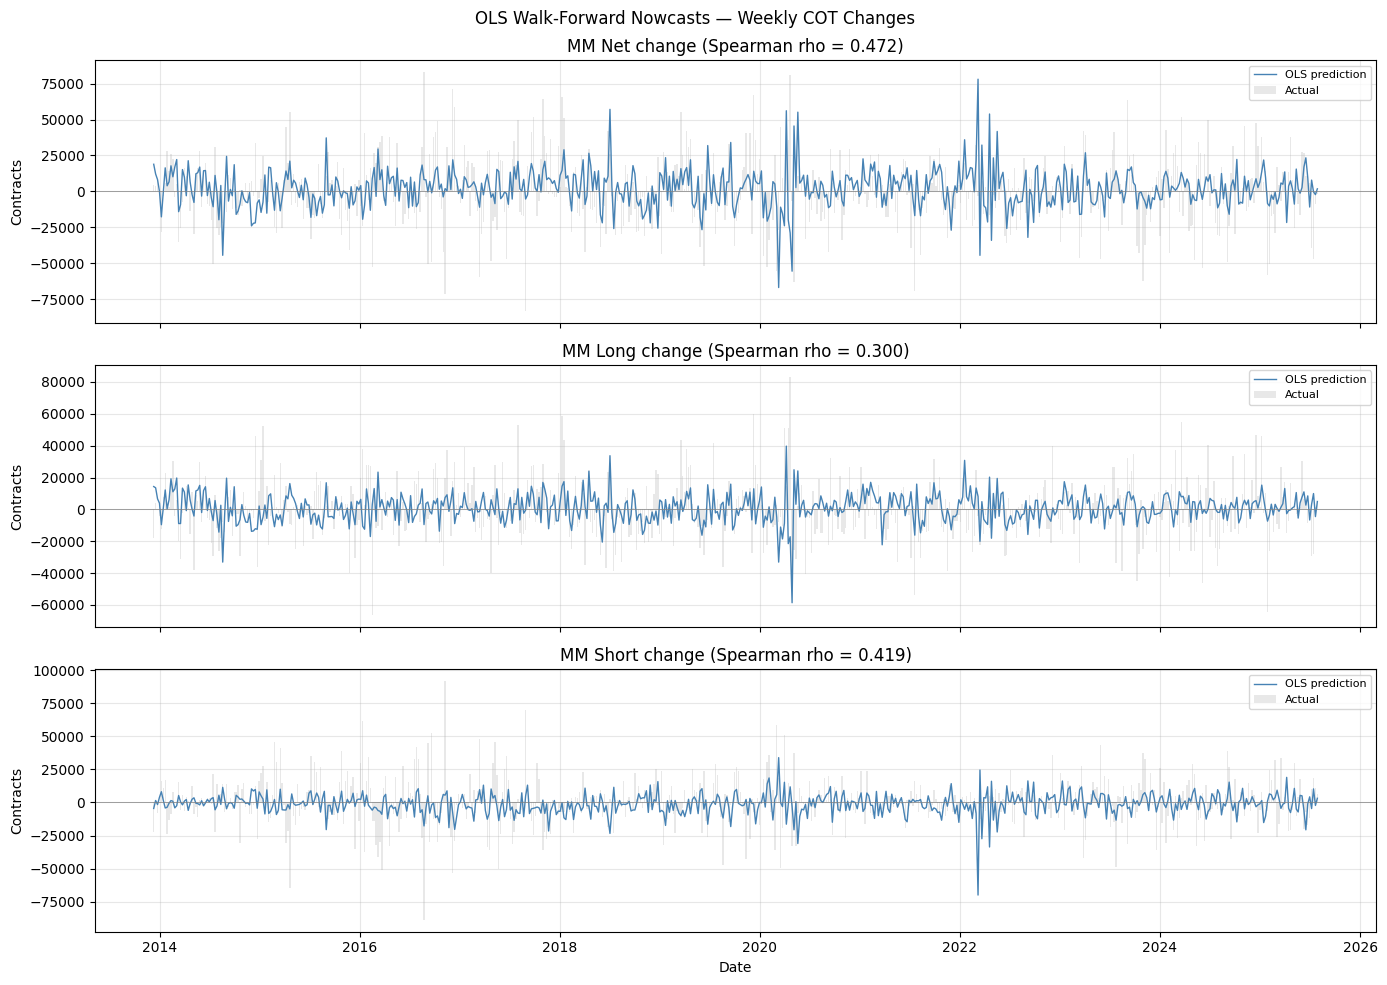

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (label, wf) in zip(axes, results.items()):
    ax.bar(wf['date'], wf['actual'], width=5, alpha=0.5,
           color='lightgrey', label='Actual')
    ax.plot(wf['date'], wf['pred'], color='steelblue',
            linewidth=1, label='OLS prediction')
    ax.axhline(0, color='grey', lw=0.5)

    rho = stats.spearmanr(wf['pred'].dropna(), wf['actual'].dropna()).statistic
    ax.set_title(f'{label} change (Spearman rho = {rho:.3f})')
    ax.set_ylabel('Contracts')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Date')
plt.suptitle('OLS Walk-Forward Nowcasts — Weekly COT Changes', fontsize=12)
plt.tight_layout()
plt.show()

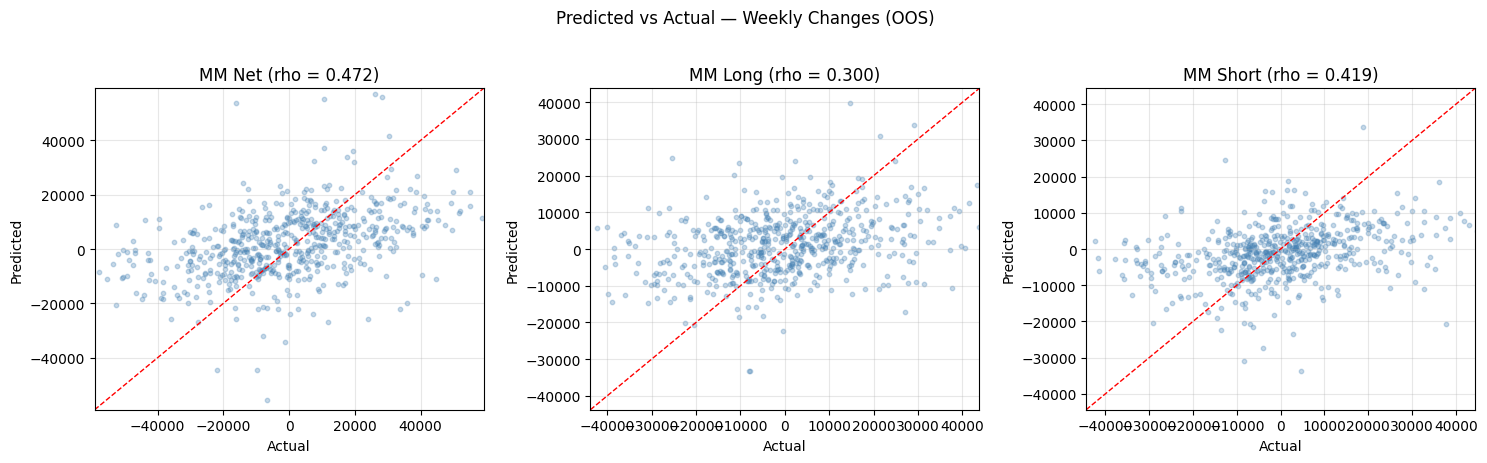

In [8]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (label, wf) in zip(axes, results.items()):
    p = wf['pred'].values
    a = wf['actual'].values
    mask = ~(np.isnan(p) | np.isnan(a))
    rho, _ = stats.spearmanr(p[mask], a[mask])
    ax.scatter(a[mask], p[mask], alpha=0.3, s=10, color='steelblue')
    lim = np.percentile(np.abs(np.concatenate([a[mask], p[mask]])), 98) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label} (rho = {rho:.3f})')

plt.suptitle('Predicted vs Actual — Weekly Changes (OOS)', y=1.02)
plt.tight_layout()
plt.show()

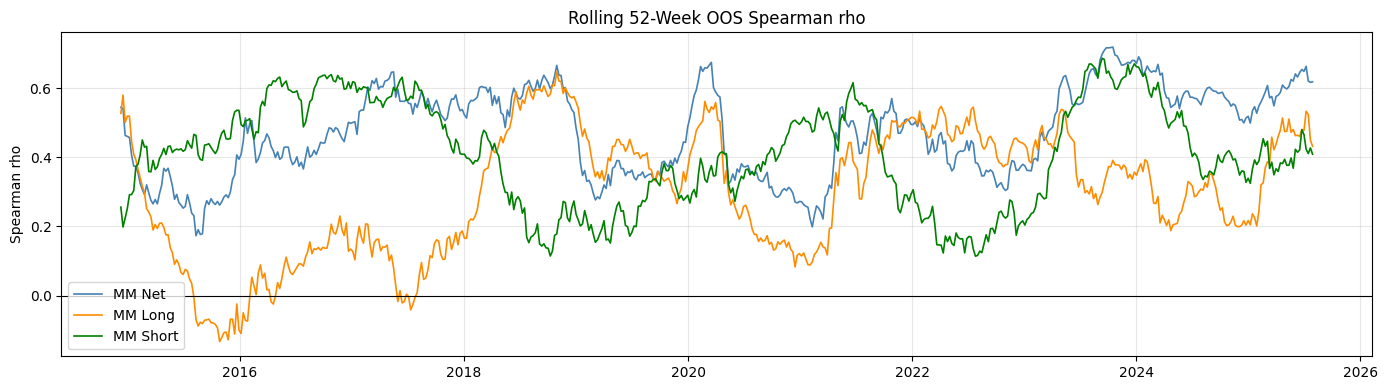

In [9]:
# Rolling 52-week Spearman rho
WINDOW = 52

fig, ax = plt.subplots(figsize=(14, 4))
colors = {'MM Net': 'steelblue', 'MM Long': 'darkorange', 'MM Short': 'green'}

for label, wf in results.items():
    p = wf['pred'].values
    a = wf['actual'].values
    rolling = [
        stats.spearmanr(p[max(0,i-WINDOW):i], a[max(0,i-WINDOW):i]).statistic
        if i >= WINDOW else np.nan
        for i in range(len(p))
    ]
    ax.plot(wf['date'], rolling, label=label, color=colors[label], linewidth=1.2)

ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Rolling {WINDOW}-Week OOS Spearman rho')
ax.set_ylabel('Spearman rho')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature coefficients (last fit)

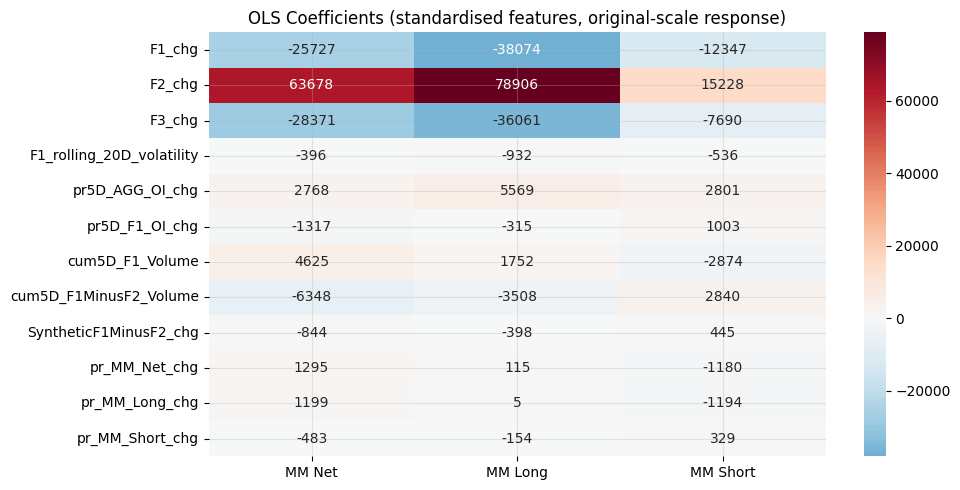

In [10]:
import seaborn as sns

# Fit final OLS on all data to inspect coefficients
coefs = {}
for label, col in RESPONSES.items():
    y = clean[col].values
    pipe = Pipeline([('scaler', StandardScaler()), ('ols', LinearRegression())])
    pipe.fit(X_all, y)
    coefs[label] = pipe.named_steps['ols'].coef_

coef_df = pd.DataFrame(coefs, index=[
    f.replace('prior_report_ManagedMoney_', 'pr_MM_')
     .replace('prior_cumulative_5D_', 'cum5D_')
     .replace('prior_5D_', 'pr5D_')
     .replace('F1_RolledPrice_', 'F1_')
     .replace('F2_RolledPrice_', 'F2_')
     .replace('F3_RolledPrice_', 'F3_')
     .replace('SyntheticF1MinusF2_RolledPrice_', 'Synth_')
     .replace('Position_change', '_chg')
     .replace('_change', '_chg')
    for f in FEATURES
])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(coef_df, annot=True, fmt='.0f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('OLS Coefficients (standardised features, original-scale response)')
plt.tight_layout()
plt.show()